<a href="https://colab.research.google.com/github/meryalvesalves6-lgtm/Engenharia_de_Prompt_Aplicacao_AI/blob/main/Aula08_AutomacaoAI_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula:08_AutomacaoAI

*Merielly dos Santos Alves*

In [ ]:
# Importa a biblioteca 'random' para simular leituras de temperatura.
import random

def verificar_temperatura():
    """Simula a verificação da temperatura do sistema e retorna um valor.

    Em um cenário real, esta função seria substituída pela leitura de um sensor
    de hardware ou por uma biblioteca específica do sistema (ex: psutil).
    A temperatura simulada varia entre 25.0°C e 35.0°C.
    """
    # Gera um número de ponto flutuante aleatório para a temperatura.
    temperatura_simulada = random.uniform(25.0, 35.0)
    return temperatura_simulada

def exibir_alerta_temperatura(temperatura):
    """Verifica a temperatura e retorna uma mensagem de alerta se estiver muito alta.

    Args:
        temperatura (float): A temperatura atual do sistema em graus Celsius.

    Returns:
        str: Uma mensagem indicando a temperatura e, se aplicável, um alerta.
    """
    # Define o limiar de temperatura para o alerta.
    limite = 30.0

    # Inicia a construção da mensagem de saída.
    mensagem = "Temperatura atual do sistema: " + f"{temperatura:.2f}°C" + "\n"

    # Verifica se a temperatura excede o limiar.
    if temperatura > limite:
        # Adiciona a mensagem de superaquecimento usando concatenação.
        mensagem += "ALERTA: Superaquecimento detectado! Temperatura acima de " + str(limite) + "°C."
    else:
        # Adiciona a mensagem de temperatura normal.
        mensagem += "Temperatura do sistema está normal."

    return mensagem

# --- Bloco de execução principal do script ---

# Obtém a temperatura simulada do sistema.
temperatura_atual_sistema = verificar_temperatura()

# Gera a mensagem de alerta/status da temperatura.
mensagem_alerta = exibir_alerta_temperatura(temperatura_atual_sistema)

# Exibe a mensagem gerada.
print(mensagem_alerta)


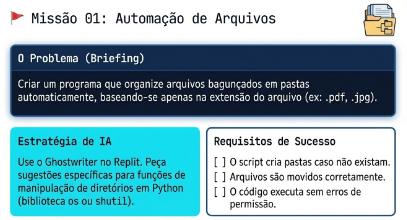

In [ ]:
import os
import shutil

def organizar_arquivos_por_extensao(diretorio_origem):
    """
    Organiza arquivos em um diretório específico, movendo-os para subpastas
    criadas com base na extensão do arquivo.

    Args:
        diretorio_origem (str): O caminho do diretório contendo os arquivos a serem organizados.
    """
    if not os.path.exists(diretorio_origem):
        print(f"Erro: O diretório de origem '{diretorio_origem}' não existe.")
        return

    print(f"Iniciando organização no diretório: {diretorio_origem}")

    # Itera sobre todos os itens no diretório de origem
    for item_nome in os.listdir(diretorio_origem):
        caminho_completo_item = os.path.join(diretorio_origem, item_nome)

        # Verifica se é um arquivo (e não um diretório)
        if os.path.isfile(caminho_completo_item):
            # Obtém o nome base e a extensão do arquivo
            _, extensao = os.path.splitext(item_nome)
            extensao = extensao.lower() # Converte para minúsculas para padronização

            # Ignora arquivos sem extensão (ou diretórios que 'parecem' ter extensão)
            if not extensao: # Se a extensão estiver vazia, ignora
                print(f"Ignorando arquivo sem extensão: {item_nome}")
                continue

            # Remove o ponto inicial da extensão para usar como nome da pasta
            nome_pasta_extensao = extensao[1:] if extensao.startswith('.') else extensao

            # Define o caminho da pasta de destino
            pasta_destino = os.path.join(diretorio_origem, nome_pasta_extensao)

            # Cria a pasta de destino se ela não existir
            if not os.path.exists(pasta_destino):
                os.makedirs(pasta_destino)
                print(f"Pasta '{pasta_destino}' criada.")

            # Define o novo caminho completo do arquivo
            novo_caminho_arquivo = os.path.join(pasta_destino, item_nome)

            # Move o arquivo para a pasta de destino
            try:
                shutil.move(caminho_completo_item, novo_caminho_arquivo)
                print(f"Arquivo '{item_nome}' movido para '{nome_pasta_extensao}/'.")
            except Exception as e:
                print(f"Erro ao mover '{item_nome}': {e}")

    print("Organização concluída!")

# --- Bloco de teste e demonstração ---

# Define um diretório de trabalho para a demonstração
diretorio_teste = "./arquivos_para_organizar"

# Limpa o diretório de teste se ele já existir
if os.path.exists(diretorio_teste):
    shutil.rmtree(diretorio_teste)

# Cria o diretório de teste
os.makedirs(diretorio_teste)
print(f"Diretório de teste '{diretorio_teste}' criado.")

# Cria alguns arquivos de exemplo (aumentando a variedade para 10 testes)
arquivos_exemplo = [
    "documento1.pdf", "relatorio_final.pdf", "contrato_assinado.pdf", "manual.pdf", # Teste 1: PDF
    "foto_ferias.jpg", "selfie.jpeg", "paisagem_montanha.png", "icone_app.gif", "imagem.bmp", # Teste 2: Imagens
    "plano_projeto.xlsx", "orcamento_anual.csv", "dados_vendas.csv", "relatorio_trimestral.docx", # Teste 3: Documentos de escritório
    "nota_importante.txt", "log_sistema.txt", "config.ini", # Teste 4: Textos e configurações
    "README", "CHANGELOG", # Teste 5: Arquivos sem extensão
    "codigo_principal.py", "script_web.js", "estilo_site.css", "pagina_inicial.html", "app.java", "main.cpp", # Teste 6: Código
    "musica_favorita.mp3", "podcast_episodio.wav", "filme_curta.mp4", "video_treinamento.avi", # Teste 7: Mídia
    "backup_geral.zip", "arquivos_antigos.rar", "dados_compactados.tar.gz", # Teste 8: Arquivos compactados
    "documento.final.v3.pdf", "relatorio.2023.xlsx", # Teste 9: Nomes com múltiplos pontos
    "apresentacao.pptx", "desenho.svg" # Teste 10: Outros formatos comuns
]

for nome_arquivo in arquivos_exemplo:
    caminho_arquivo = os.path.join(diretorio_teste, nome_arquivo)
    with open(caminho_arquivo, "w") as f:
        f.write(f"Conteúdo de {nome_arquivo}")
    print(f"Arquivo '{nome_arquivo}' criado em '{diretorio_teste}'.")

print("\n--- Arquivos antes da organização ---")
print(os.listdir(diretorio_teste))

# Chama a função para organizar os arquivos
organizar_arquivos_por_extensao(diretorio_teste)

print("\n--- Arquivos e Pastas após a organização ---")
# Lista o conteúdo do diretório de teste após a organização
for root, dirs, files in os.walk(diretorio_teste):
    nivel = root.replace(diretorio_teste, '').count(os.sep)
    identacao = '    ' * (nivel)
    print(f'{identacao}{os.path.basename(root)}/')
    sub_identacao = '    ' * (nivel + 1)
    for f in files:
        print(f'{sub_identacao}{f}')


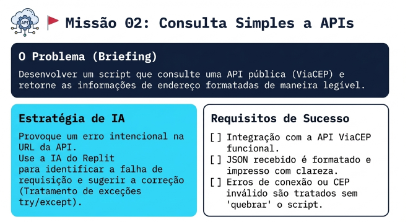

In [2]:
import requests # Importa a biblioteca 'requests' para fazer requisições HTTP a APIs externas.
import json     # Importa a biblioteca 'json' para trabalhar com dados no formato JSON.

def consultar_cep(cep):
    """
    Consulta a API pública do ViaCEP para obter informações de endereço
    com base em um CEP fornecido.

    Args:
        cep (str): O Código de Endereçamento Postal a ser consultado. Deve ser uma string
                   que contenha apenas números, mas a função tentará limpar caracteres não numéricos.

    Returns:
        dict or None: Retorna um dicionário contendo os dados do endereço (logradouro, bairro,
                      localidade, etc.) se a consulta for bem-sucedida. Retorna None
                      se houver um erro na requisição, o CEP for inválido ou não for encontrado.
    """
    # Remove qualquer caractere que não seja um dígito do CEP para garantir um formato limpo.
    # Por exemplo, '01001-000' se torna '01001000'.
    cep = ''.join(filter(str.isdigit, cep))

    # Verifica se o CEP resultante possui exatamente 8 dígitos. Se não tiver,
    # exibe uma mensagem de erro e retorna None, pois o ViaCEP espera 8 dígitos.
    if len(cep) != 8:
        print("Erro: O CEP deve conter 8 dígitos numéricos. Por favor, verifique o número digitado.")
        return None

    # Constrói a URL para a requisição à API do ViaCEP usando o CEP formatado.
    # O formato da API é "https://viacep.com.br/ws/{cep}/json/".
    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        # Realiza uma requisição GET para a URL da API.
        response = requests.get(url)

        # Lança uma exceção HTTPError para respostas com status de erro (4xx ou 5xx).
        # Isso ajuda a identificar problemas de conexão ou de servidor da API.
        response.raise_for_status()

        # Converte a resposta JSON em um dicionário Python.
        dados = response.json()

        # A API do ViaCEP retorna um campo 'erro' com valor 'true' se o CEP não for encontrado.
        # Verifica essa condição e exibe uma mensagem apropriada.
        if 'erro' in dados and dados['erro'] == True:
            print(f"Erro: CEP '{cep}' não encontrado ou inválido. Por favor, verifique se o CEP está correto.")
            return None

        # Se a consulta for bem-sucedida e não houver erro, retorna o dicionário com os dados.
        return dados
    except requests.exceptions.RequestException as e:
        # Captura exceções relacionadas a problemas de rede ou requisição (ex: sem internet).
        print(f"Erro ao conectar à API do ViaCEP: {e}")
        print("Sugestão: Verifique sua conexão com a internet ou tente novamente mais tarde. Pode ser um problema temporário com a API.")
        return None
    except json.JSONDecodeError:
        # Captura exceções se a resposta da API não for um JSON válido.
        print(f"Erro ao decodificar a resposta JSON da API para o CEP '{cep}'.")
        print("Sugestão: A API do ViaCEP retornou dados em um formato inesperado. Tente novamente ou entre em contato com o suporte da API se o problema persistir.")
        return None

def formatar_endereco(dados_endereco):
    """
    Formata os dados de endereço retornados pela API do ViaCEP em uma string legível.

    Args:
        dados_endereco (dict): Dicionário contendo os dados do endereço, geralmente
                               obtido da função `consultar_cep`.

    Returns:
        str: Uma string formatada com as informações do endereço. Se o dicionário
             estiver vazio ou None, retorna uma mensagem indicando a ausência de dados.
    """
    # Verifica se há dados de endereço para formatar.
    if not dados_endereco:
        return "Nenhum dado de endereço para formatar."

    # Constrói a string formatada usando uma f-string para o título.
    endereco_formatado = f"-- Informações do Endereço --\n"
    # Adiciona cada campo do endereço à string formatada. Usa .get(chave, 'N/A')
    # para evitar erros caso alguma chave esteja faltando no dicionário.
    endereco_formatado += f"CEP: {dados_endereco.get('cep', 'N/A')}\n"
    endereco_formatado += f"Logradouro: {dados_endereco.get('logradouro', 'N/A')}\n"
    endereco_formatado += f"Complemento: {dados_endereco.get('complemento', 'N/A')}\n"
    endereco_formatado += f"Bairro: {dados_endereco.get('bairro', 'N/A')}\n"
    endereco_formatado += f"Localidade: {dados_endereco.get('localidade', 'N/A')}\n"
    endereco_formatado += f"Estado (UF): {dados_endereco.get('uf', 'N/A')}\n"
    endereco_formatado += f"IBGE: {dados_endereco.get('ibge', 'N/A')}\n"
    endereco_formatado += f"GIA: {dados_endereco.get('gia', 'N/A')}\n"
    endereco_formatado += f"DDD: {dados_endereco.get('ddd', 'N/A')}\n"
    endereco_formatado += f"SIAFI: {dados_endereco.get('siafi', 'N/A')}\n"
    # Retorna a string completa com todas as informações formatadas.
    return endereco_formatado

# --- Bloco de Exemplo de Uso Interativo ---

# Solicita ao usuário que digite um CEP através do terminal.
# A entrada é armazenada na variável `cep_digitado`.
cep_digitado = input("Digite o CEP (apenas números): ")

# Chama a função `consultar_cep` para buscar os dados do endereço
# com base no CEP fornecido pelo usuário.
dados_do_cep = consultar_cep(cep_digitado)

# Verifica se a consulta retornou dados (ou seja, não foi None).
if dados_do_cep:
    # Se houver dados, formata-os e os imprime no console, com uma linha extra
    # para melhor separação visual.
    print("\n" + formatar_endereco(dados_do_cep))
else:
    # Se `dados_do_cep` for None (indicando um erro ou CEP não encontrado),
    # exibe uma mensagem informando que não foi possível obter as informações.
    print("Não foi possível obter informações para o CEP fornecido.")

KeyboardInterrupt: Interrupted by user

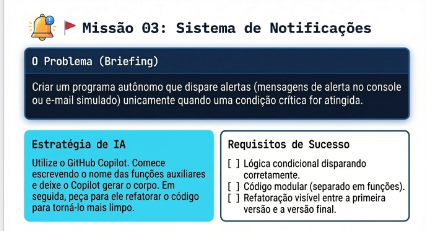

In [ ]:
import random # Importa a biblioteca 'random' para simular leituras de temperatura.
import time   # Importa a biblioteca 'time' para pausar a execução (simular intervalos de monitoramento).

def verificar_temperatura():
    """
    Simula a verificação da temperatura do sistema e retorna um valor.

    Em um cenário real, esta função seria substituída pela leitura de um sensor
    de hardware ou por uma biblioteca específica do sistema (ex: psutil).
    A temperatura simulada varia entre 25.0°C e 40.0°C para permitir que o alerta seja disparado.
    """
    # Gera um número de ponto flutuante aleatório para a temperatura.
    temperatura_simulada = random.uniform(25.0, 40.0)
    return temperatura_simulada

def enviar_email_simulado(assunto, corpo, destinatario='admin@exemplo.com'):
    """
    Simula o envio de um e-mail. Em um programa real, seria usado um módulo como smtplib.

    Args:
        assunto (str): O assunto do e-mail simulado.
        corpo (str): O corpo (conteúdo) do e-mail simulado.
        destinatario (str): O endereço de e-mail do destinatário (padrão para simulação).
    """
    print(f"--- E-MAIL SIMULADO ---\nDe: sistema@autonomo.com\nPara: {destinatario}\nAssunto: {assunto}\n\n{corpo}\n------------------------")

def programa_autonomo_monitoramento(intervalo_segundos=5, limite_temperatura=30.0):
    """
    Executa um programa autônomo que monitora a temperatura e dispara alertas.

    Args:
        intervalo_segundos (int): O tempo de espera entre cada verificação (em segundos).
        limite_temperatura (float): A temperatura limite para disparar o alerta crítico.
    """
    print("Iniciando programa autônomo de monitoramento...")
    print(f"Verificação a cada {intervalo_segundos} segundos. Limite crítico: {limite_temperatura}°C")
    print("Pressione Ctrl+C para parar o monitoramento a qualquer momento.")

    try:
        while True:
            temperatura_atual = verificar_temperatura()
            mensagem_console = f"Temperatura atual do sistema: {temperatura_atual:.2f}°C\n"

            if temperatura_atual > limite_temperatura:
                mensagem_alerta = "ALERTA CRÍTICO: Superaquecimento detectado! " \
                                  f"Temperatura ({temperatura_atual:.2f}°C) acima de {limite_temperatura}°C."
                mensagem_console += mensagem_alerta
                print(mensagem_console)

                # Dispara o e-mail simulado
                assunto_email = f"ALERTA CRÍTICO: Superaquecimento - {temperatura_atual:.2f}°C"
                corpo_email = f"O sistema atingiu uma temperatura crítica de {temperatura_atual:.2f}°C. " \
                              f"O limite configurado é de {limite_temperatura}°C. " \
                              "Por favor, tome as medidas corretivas necessárias."
                enviar_email_simulado(assunto_email, corpo_email)

            else:
                mensagem_console += "Temperatura do sistema está normal."
                print(mensagem_console)

            # Espera o intervalo definido antes da próxima verificação
            time.sleep(intervalo_segundos)

    except KeyboardInterrupt:
        print("\nMonitoramento interrompido pelo usuário.")
    except Exception as e:
        print(f"Ocorreu um erro inesperado durante o monitoramento: {e}")

# --- Bloco de execução principal do programa autônomo ---
# Define o intervalo de verificação e o limite de temperatura para este exemplo.
intervalo_de_verificacao = 3  # segundos
limite_critico_temperatura = 32.0 # Graus Celsius

# Chama a função principal para iniciar o monitoramento autônomo.
programa_autonomo_monitoramento(intervalo_de_verificacao, limite_critico_temperatura)